# 1.1 advanced: RL allocation policy
**Responsible:** _(Aldo Patrone)_

A learned allocation policy as a swappable AllocationStrategy, aligned with Middelhuis et al. (2025):
- Per-candidate scoring policy handling the variable action set, trained with **REINFORCE** (from-scratch, pure numpy).
- A state-of-the-art **MaskablePPO** variant (sb3-contrib) over the masked resource set, trained in an isolated venv via scripts/train_ppo.py.
- Reward = per-case cycle time + potential-based fairness shaping (the disclosed combined objective).

Full training is reproducible via scripts/train_rl.py / scripts/train_ppo.py. Here a short REINFORCE training is run to show learning, then the deployable policy is loaded. The evaluation metrics are in 2.5_metrics. The RL method comparison is in 2.7_evaluation.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from resources.log_loader import load_slim_log
from optimization.environment import build_env_config
from optimization.rl_agent import train, RLAllocation

cfg = build_env_config(
    load_slim_log('../data/BPI Challenge 2017.xes', '../data/bpic17_slim.parquet'),
    permissions_path='../results/permissions_roles.json',
    calendars_path='../results/availability_calendars.json',
)
print('env:', len(cfg['activity_mix']), 'activities,', len(cfg['calendars']), 'resources')

env: 26 activities, 149 resources


## Training (short REINFORCE run for illustration)
The episode return rises as the policy learns. The full runs (more episodes / PPO) are in the scripts.

first-30 avg -2.32 -> last-30 avg -1.08


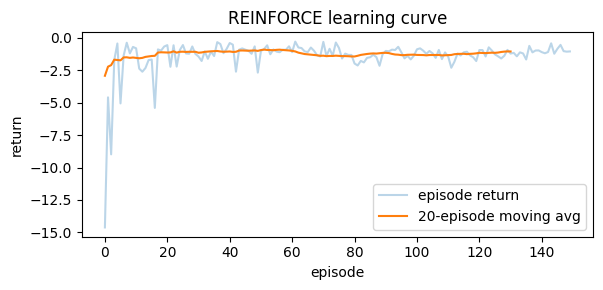

In [2]:
net, history = train(cfg, episodes=150, hidden=24, lr=0.05, ep_len=400, seed=1, entropy_beta=0.01)
h = np.array(history)
smooth = np.convolve(h, np.ones(20)/20, mode='valid')
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(h, alpha=0.3, label='episode return')
ax.plot(range(len(smooth)), smooth, label='20-episode moving avg')
ax.set_xlabel('episode'); ax.set_ylabel('return'); ax.set_title('REINFORCE learning curve'); ax.legend()
fig.tight_layout(); fig.savefig('../results/rl_learning_curve.png', dpi=120)
print('first-30 avg %.2f -> last-30 avg %.2f' % (h[:30].mean(), h[-30:].mean()))

## Deployable policy
The trained policy (from scripts/train_rl.py) is serialized to results/rl_policy.json and loaded as an AllocationStrategy. Inference is numpy-only. Postpone maps to returning None (the core suspends/retries).

In [3]:
rl = RLAllocation.load('../results/rl_policy.json')
class _Ctx:
    load = {'User_1': 5.0, 'User_2': 0.0}
    busy = set()
    class event:
        activity = 'W_Validate application'
print('RLAllocation.pick ->', rl.pick({'User_1', 'User_2', 'User_3'}, _Ctx()))
print('OK: trained RL policy runs via the standard pick(candidates, context) interface')

RLAllocation.pick -> User_2
OK: trained RL policy runs via the standard pick(candidates, context) interface
